In [42]:
import numpy as np
import matplotlib.pyplot as plt     
import pandas as pd
from  sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
import sklearn.metrics as sm

In [2]:
xx=np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
yy=np.array([1,4,9,16,25,36,49,64,81,100])

In [5]:
x_train,x_test,y_train,y_test=train_test_split(xx,yy,test_size=0.2,random_state=42)

In [31]:
pl=PolynomialFeatures(degree=2)
xx_train_poly=pl.fit_transform(x_train)
xx_test_poly=pl.transform(x_test)

In [32]:
lm=LinearRegression()
lm.fit(xx_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
perd=lm.predict(xx_test_poly)

In [41]:
mae=sm.mean_absolute_error(y_test,perd)
mse=sm.mean_squared_error(y_test,perd)  
rmse=np.sqrt(mse)
print(f"MAE: {mae}")
print(f"MSE: {mse}")    
print(f"RMSE: {rmse}")

MAE: 1.3766765505351941e-14
MSE: 1.8972104770565334e-28
RMSE: 1.377392637215886e-14


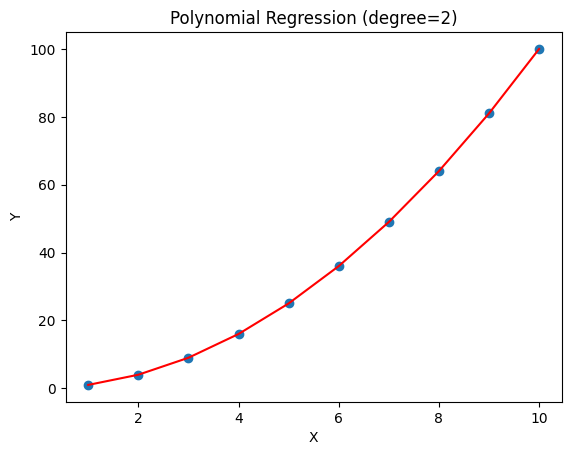

In [38]:
# plt.scatter(xx,yy)
# plt.plot(xx,pl.fit_transform(xx)@lm.coef_,color='red')
xx_poly = pl.transform(xx)

plt.scatter(xx, yy)                    # actual data
plt.plot(xx, lm.predict(xx_poly), color='red')  # polynomial curve

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression (degree=2)")
plt.show()